# Cost of living

Trying to answer: 
<p>How much does a family need to make a year for this - Starting a family in a nice town, with enough financial success to be generally free from worry. The traditional idea of "making it". </p>

## Is the American Dream still achievable?

**Question:** Has income growth kept up with the cost of living — broadly, and in the big-ticket categories (housing, healthcare, higher ed, food)?

**Approach:** Index per-capita personal income and PCE price indexes to **2000 = 100**. A series above 100 has grown since 2000; if income sits above a cost-of-living series, that cost has gotten *more affordable* relative to the average paycheck. If it sits below, the squeeze is real.

Data:
- Income → `cleaned_income_with_state.csv` (BEA per-capita personal income, by state)
- Prices → `Price_Indexes_for_Personal_Consumption_Expenditures_by_Function.csv` (BEA T2.5.4, base 2017=100)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

income = pd.read_csv("../../data/cleaned/cleaned_income_with_state.csv")
prices = pd.read_csv("../../data/cleaned/Price_Indexes_for_Personal_Consumption_Expenditures_by_Function.csv")

# strip BEA footnote markers like \1\, \2\ from category labels
prices["category"] = prices["category"].str.replace(r"\\\d+\\", "", regex=True).str.strip()

year_cols = [c for c in prices.columns if str(c).isdigit()]
print("price years:", year_cols[0], "→", year_cols[-1])
print("income cols tail:", list(income.columns[-5:]))

price years: 1929 → 2024
income cols tail: ['2022', '2023', '2024', '2025', 'Region']


In [2]:
# Build US per-capita income by aggregating states:
#   total personal income ($M)  /  total population  * 1,000,000
yr_income = [c for c in income.columns if str(c).isdigit()]

pi  = income[income["LineCode"] == 1].set_index("GeoName")[yr_income].sum()   # $ millions
pop = income[income["LineCode"] == 2].set_index("GeoName")[yr_income].sum()   # persons

us_pci = (pi * 1_000_000) / pop          # dollars per person
us_pci.index = us_pci.index.astype(int)
us_pci = us_pci.sort_index()
us_pci.tail()

2021    64704.403646
2022    66309.120089
2023    70017.762996
2024    73227.118349
2025    76383.540177
dtype: float64

In [3]:
# Pick the cost-of-living categories most tied to a family's budget
picks = {
    "Personal consumption expenditures":                                   "Overall cost of living (PCE)",
    "Housing":                                                             "Housing",
    "Rental of tenant-occupied nonfarm housing":                           "Rent (tenant)",
    "Health":                                                              "Healthcare",
    "Higher education":                                                    "Higher education",
    "Food and nonalcoholic beverages purchased for off-premises consumption": "Groceries",
}

cost = prices[prices["category"].isin(picks)].set_index("category")[year_cols].T
cost.index = cost.index.astype(int)
cost = cost.rename(columns=picks).sort_index()

# Align both series on a common year range
base = 2000
start, end = base, min(us_pci.index.max(), cost.index.max())
cost = cost.loc[start:end]
inc  = us_pci.loc[start:end]

# Re-index everything so 2000 = 100 (growth comparison)
cost_idx = cost / cost.loc[base] * 100
inc_idx  = inc  / inc.loc[base]  * 100

cost_idx.tail(), inc_idx.tail()

(category  Overall cost of living (PCE)   Groceries     Housing  Rent (tenant)  \
 2020                        141.781583  148.308783  172.238928     185.227900   
 2021                        147.614532  153.280043  176.570820     189.404804   
 2022                        157.270190  171.141271  186.911921     200.844072   
 2023                        163.245374  180.308444  201.077492     216.806231   
 2024                        167.519168  182.527151  211.921318     227.869428   
 
 category  Healthcare  Higher education  
 2020      159.196183        264.366505  
 2021      162.412054        266.673281  
 2022      166.440197        272.415418  
 2023      170.788417        277.661474  
 2024      175.209107        282.428812  ,
 2020    193.608473
 2021    211.775263
 2022    217.027444
 2023    229.165703
 2024    239.669812
 dtype: float64)

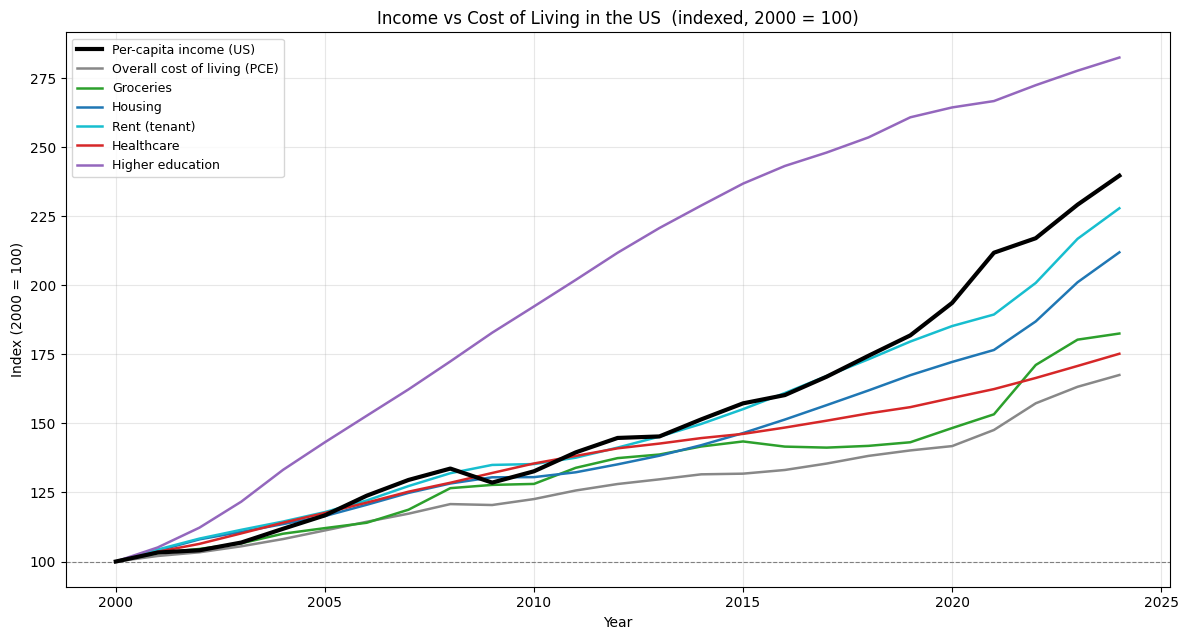

In [4]:
fig, ax = plt.subplots(figsize=(12, 6.5))

# income bold; costs thinner
ax.plot(inc_idx.index, inc_idx.values, color="black", lw=3,
        label="Per-capita income (US)", zorder=5)

colors = {
    "Overall cost of living (PCE)": "#888888",
    "Housing":                      "#1f77b4",
    "Rent (tenant)":                "#17becf",
    "Healthcare":                   "#d62728",
    "Higher education":             "#9467bd",
    "Groceries":                    "#2ca02c",
}
for col in cost_idx.columns:
    ax.plot(cost_idx.index, cost_idx[col], lw=1.8, label=col, color=colors.get(col))

ax.axhline(100, color="gray", ls="--", lw=0.8)
ax.set_title(f"Income vs Cost of Living in the US  (indexed, {base} = 100)")
ax.set_xlabel("Year"); ax.set_ylabel(f"Index ({base} = 100)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

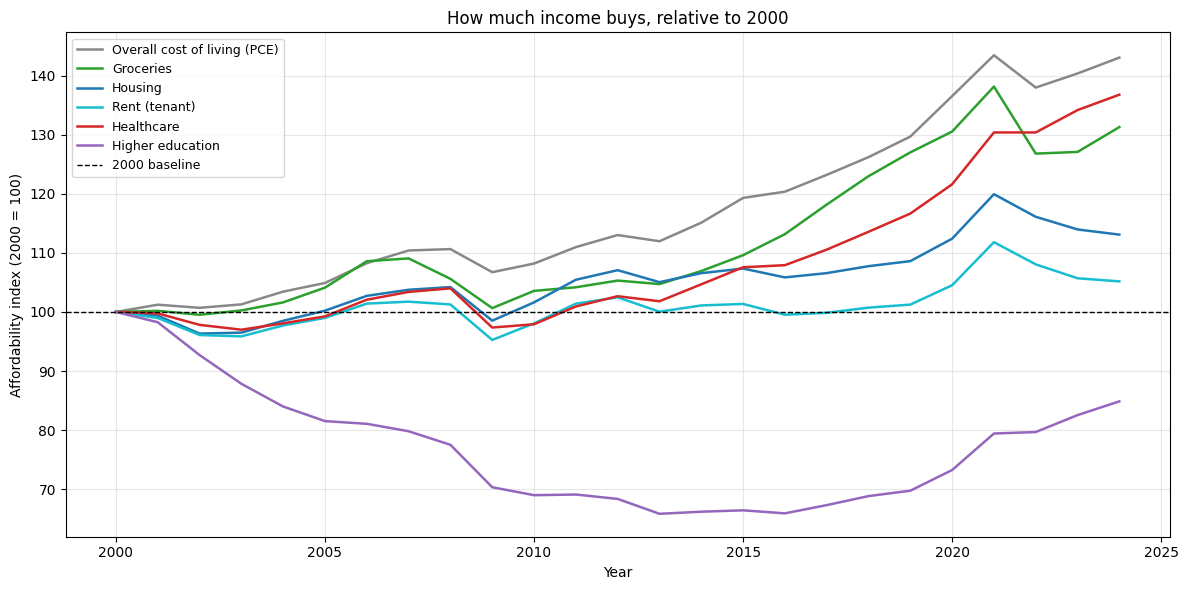


=== Latest affordability (vs 2000) ===
Higher education                 84.9
Rent (tenant)                   105.2
Housing                         113.1
Groceries                       131.3
Healthcare                      136.8
Overall cost of living (PCE)    143.1
Name: 2024, dtype: float64


In [5]:
# "Real" buying power by category: how much a year of income buys of each thing,
# indexed so 2000 = 100.  Above 100 = more affordable than in 2000.  Below 100 = harder.
affordability = inc_idx.to_frame("income").join(cost_idx)
for col in cost_idx.columns:
    affordability[col] = affordability["income"] / affordability[col] * 100
affordability = affordability.drop(columns="income")

fig, ax = plt.subplots(figsize=(12, 6))
for col in affordability.columns:
    ax.plot(affordability.index, affordability[col], lw=1.8, label=col, color=colors.get(col))
ax.axhline(100, color="black", ls="--", lw=1, label=f"{base} baseline")
ax.set_title(f"How much income buys, relative to {base}")
ax.set_xlabel("Year"); ax.set_ylabel(f"Affordability index ({base} = 100)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\n=== Latest affordability (vs 2000) ===")
print(affordability.iloc[-1].round(1).sort_values())

### Reading the charts (2000 → 2024)

Per-capita income grew to **~240** (2000 = 100). Where did that buying power go?

| Category | Price index 2024 (2000=100) | Income ran ahead? |
|---|---:|---|
| Groceries | 183 | ✅ yes, by a lot |
| Healthcare | 175 | ✅ yes |
| Overall PCE (headline inflation) | 168 | ✅ yes |
| Housing | 212 | ✅ barely |
| Rent (tenant) | 228 | ⚠️ barely |
| **Higher education** | **282** | ❌ **no — college outpaced paychecks** |

**Takeaway:** On paper, the American Dream math still works *on average* — nominal income grew faster than overall cost of living, so real buying power is higher than in 2000. But the two things that define "making it" for a family — **owning / renting a decent home** and **paying for college** — have eaten most of that gain. Higher education is the only category that has outright *gotten harder* to afford. That lines up with how the dream *feels* unattainable even while the aggregate numbers say it isn't.

Caveat: per-capita income is a mean, not a median — it's pulled up by top earners, so a typical household's experience is worse than what this chart implies.

## Who is the Dream working for? — Income by industry

Per-capita income tells us the *average* American did okay.  But averages hide winners and losers.  Here we switch from national per-capita income to **wages per full-time equivalent employee, by industry** (BEA T6.6D) to ask: which kinds of work kept up, and which fell behind?

BEA does not tag wages by worker education level, so we use industry as a proxy for the college-degree question — splitting industries into "degree-heavy" (Information, Finance, Professional & Technical, Educational services, Health care, Management of companies) and "non-degree-heavy" (Construction, Retail trade, Accommodation & food, Transportation, Agriculture).  This is an **industry-composition proxy, not a true education cut** — plenty of non-degree workers are employed in degree-heavy industries and vice versa.

In [ ]:
# Load BEA T6.6D: wages & salaries per FTE employee, by industry (1998–2024).
# Header is 7 rows of BEA metadata; real table starts at row 8.
wages_path = ("../../data/original(do not modify)/GDP_and_personal_income/"
              "Income_and_Employment_by_Industry/"
              "Annual_T6.6D._Wages_and_Salaries_Per_Full-Time_Equivalent_Employee_by_Industry.xlsx")
wages = pd.read_excel(wages_path, header=7)
wages.columns = ["Line", "Industry", "Code"] + [int(c) for c in wages.columns[3:]]
wages = wages.dropna(subset=["Industry"]).copy()

# strip BEA footnote markers like \1\, \2\ (same pattern used earlier)
wages["Industry"] = wages["Industry"].str.replace(r"\\\d+\\", "", regex=True).str.strip()

wage_year_cols = [c for c in wages.columns if isinstance(c, int)]
wages[wage_year_cols] = wages[wage_year_cols].apply(pd.to_numeric, errors="coerce")
wages = wages.set_index("Industry")

print("wage years:", wage_year_cols[0], "→", wage_year_cols[-1])
print("industries:", len(wages))

In [ ]:
# Pick a representative spread of industries and rebase to 2000 = 100.
industry_picks = [
    "Private industries",                                  # the baseline average
    "Information",                                         # tech/media  (degree-heavy)
    "Finance and insurance",                               # (degree-heavy)
    "Professional, scientific, and technical services",    # (degree-heavy)
    "Educational services",                                # (degree-heavy, lower-paid)
    "Construction",                                        # (non-degree)
    "Retail trade",                                        # (non-degree)
    "Accommodation and food services",                     # (non-degree, lowest-paid)
]

yrs = list(range(base, 2025))                              # reuse base=2000 from earlier
w = wages.loc[industry_picks, yrs].T
wage_idx = w / w.loc[base] * 100

fig, ax = plt.subplots(figsize=(12, 6.5))

industry_colors = {
    "Private industries":                               "black",
    "Information":                                      "#1f77b4",
    "Finance and insurance":                            "#2ca02c",
    "Professional, scientific, and technical services": "#17becf",
    "Educational services":                             "#9467bd",
    "Construction":                                     "#ff7f0e",
    "Retail trade":                                     "#d62728",
    "Accommodation and food services":                  "#8c564b",
}
for col in wage_idx.columns:
    lw = 3 if col == "Private industries" else 1.6
    ax.plot(wage_idx.index, wage_idx[col], lw=lw,
            color=industry_colors.get(col), label=col,
            zorder=5 if col == "Private industries" else 2)

# Overlay overall inflation (from earlier cost_idx) so readers see who beat inflation
ax.plot(cost_idx.index, cost_idx["Overall cost of living (PCE)"],
        lw=1.4, ls="--", color="gray", label="Overall cost of living (PCE)")

ax.axhline(100, color="gray", lw=0.8)
ax.set_title(f"Wages per FTE worker, by industry (indexed, {base} = 100)")
ax.set_xlabel("Year"); ax.set_ylabel(f"Index ({base} = 100)")
ax.legend(loc="upper left", fontsize=8.5)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n=== 2024 wage index ({base}=100), sorted ===")
print(wage_idx.loc[2024].sort_values(ascending=False).round(1))
print(f"\n=== 2024 dollar wages ===")
print(w.loc[2024].sort_values(ascending=False).astype(int))

In [ ]:
# Degree-heavy vs non-degree-heavy industry proxy.
# Simple (unweighted) mean across industries in each bucket — treats each industry equally,
# which is intentional: we're comparing *types of work*, not head-count totals.
degree_heavy = [
    "Information",
    "Finance and insurance",
    "Professional, scientific, and technical services",
    "Educational services",
    "Health care and social assistance",
    "Management of companies and enterprises",
]
non_degree = [
    "Construction",
    "Retail trade",
    "Accommodation and food services",
    "Transportation and warehousing",
    "Agriculture, forestry, fishing, and hunting",
]

def bucket_index(members):
    sub = wages.loc[members, yrs].T
    return (sub / sub.loc[base] * 100).mean(axis=1)

bucket_idx = pd.DataFrame({
    "Degree-heavy industries":     bucket_index(degree_heavy),
    "Non-degree-heavy industries": bucket_index(non_degree),
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [3, 2]})

# Left: indexed growth over time
ax1 = axes[0]
ax1.plot(bucket_idx.index, bucket_idx["Degree-heavy industries"],
         lw=2.5, color="#1f77b4", label="Degree-heavy")
ax1.plot(bucket_idx.index, bucket_idx["Non-degree-heavy industries"],
         lw=2.5, color="#ff7f0e", label="Non-degree-heavy")
ax1.plot(cost_idx.index, cost_idx["Overall cost of living (PCE)"],
         lw=1.4, ls="--", color="gray", label="Overall cost of living (PCE)")
ax1.axhline(100, color="gray", lw=0.8)
ax1.set_title(f"Wage growth by industry group  ({base} = 100)")
ax1.set_xlabel("Year"); ax1.set_ylabel(f"Index ({base} = 100)")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# Right: 2024 dollar levels (the gap the index chart hides)
ax2 = axes[1]
levels_2024 = pd.Series({
    "Degree-heavy (avg)":     wages.loc[degree_heavy, 2024].mean(),
    "Non-degree-heavy (avg)": wages.loc[non_degree, 2024].mean(),
})
bars = ax2.barh(levels_2024.index, levels_2024.values,
                color=["#1f77b4", "#ff7f0e"])
for bar, v in zip(bars, levels_2024.values):
    ax2.text(v + 2000, bar.get_y() + bar.get_height()/2,
             f"${v:,.0f}", va="center", fontsize=10)
ax2.set_title("Average 2024 wages ($ per FTE)")
ax2.set_xlabel("Dollars per FTE employee")
ax2.set_xlim(0, levels_2024.max() * 1.25)
ax2.grid(alpha=0.3, axis="x")

plt.tight_layout(); plt.show()

print(f"\n2024 mean-of-index (2000=100):  degree-heavy = {bucket_idx.loc[2024, 'Degree-heavy industries']:.1f}  |  "
      f"non-degree-heavy = {bucket_idx.loc[2024, 'Non-degree-heavy industries']:.1f}")
print(f"2024 dollar wages (avg across bucket):  degree-heavy = ${levels_2024.iloc[0]:,.0f}  |  "
      f"non-degree-heavy = ${levels_2024.iloc[1]:,.0f}")

### Reading the industry charts

**Who won the last 25 years?**

| Industry | Wage index 2024 (2000=100) | 2024 avg wage |
|---|---:|---:|
| Information (tech/software/media) | **298** | $187k |
| Accommodation & food services | 244 | $44k |
| Finance and insurance | 226 | $146k |
| Construction | 220 | $85k |
| **Private industries (all)** | **216** | **$84k** |
| Professional, scientific, & technical | 216 | $135k |
| Educational services | 208 | $61k |
| Retail trade | 189 | $50k |

**Three things to notice:**

1. **Tech ran away with it.** Information-sector wages nearly *tripled*, outpacing even higher-education inflation (282). If you're a software engineer, the Dream is very much alive.
2. **Accommodation/food grew fast *in percent terms* (+144%), but from a low base** — 2024 wages there are still only ~$44k, the lowest on this chart. Index growth doesn't pay rent; dollar levels do. This is the most important caveat to the "indexed" framing.
3. **Degree-heavy beat non-degree-heavy modestly in growth (229 vs 216, a ~13-point gap), but the dollar gap is enormous — ~$128k vs ~$61k in 2024.** The premium for "degree-heavy" work is driven less by faster *growth* and more by a persistently higher *level*.

**Two honest caveats:**
- This is an industry proxy. A welder at a tech company is in "degree-heavy" here; an accountant at a construction firm is in "non-degree-heavy." A real education cut would need BLS/Census data and would likely show a larger gap.
- The "Private industries (all)" wage index (216) is lower than the per-capita *income* index from the first chart (240) because personal income also includes transfers, dividends, and rental income — non-wage sources have grown faster than wages alone. So the "average American did okay" story above is partly carried by things other than paychecks.

**Where this leaves the Dream:** available, but increasingly conditional on which industry you work in. Housing and college eat the biggest bites; tech and finance workers can still afford them, retail and food workers largely can't.

## Housing under the microscope — burden and the renter / owner split

The first chart showed housing prices outrunning overall inflation, but it didn't answer two follow-on questions:

1. **Has housing actually consumed a larger slice of income over time?**  Price growth matters less than the *share of the paycheck* it takes.
2. **Has the squeeze hit renters and owners the same way?**  BEA splits housing into two flavors: cash rent paid by tenants, and the "imputed" rent BEA calculates for owner-occupied homes (what owners would pay themselves if they rented the home they live in). The two don't move together.

We'll use PCE spending in dollars (`annual_Personal_Consumption_Expenditures_by_Function.csv`) for burden, and the existing PCE price indexes for the renter / owner comparison.

In [ ]:
# Load PCE $ spending by function and compute housing burden (% of total personal income).
# `pi` (total US personal income, $M) is already in scope from cell eb12c7db.
pce_spend = pd.read_csv("../../data/cleaned/annual_Personal_Consumption_Expenditures_by_Function.csv")
pce_spend["category"] = pce_spend["category"].str.replace(r"\\\d+\\", "", regex=True).str.strip()

spend_years = [c for c in pce_spend.columns if str(c).isdigit()]

housing_rows = {
    "Housing, utilities, and fuels":                        "All housing + utilities",
    "Rental of tenant-occupied nonfarm housing":            "Tenant rent (cash)",
    "Imputed rental of owner-occupied nonfarm housing":     "Owner-occupied (imputed)",
}

hspend = (pce_spend[pce_spend["category"].isin(housing_rows)]
          .set_index("category")[spend_years].T
          .rename(columns=housing_rows))
hspend.index = hspend.index.astype(int)
hspend = hspend.sort_index()

# align pi (total PI in $M) with hspend years
pi_int = pi.copy(); pi_int.index = pi_int.index.astype(int)
common = hspend.index.intersection(pi_int.index)
burden = hspend.loc[common].div(pi_int.loc[common], axis=0) * 100          # % of personal income

# Plot burden 2000 → 2024
burden_w = burden.loc[base:2024]

fig, ax = plt.subplots(figsize=(12, 6))
order = ["All housing + utilities", "Owner-occupied (imputed)", "Tenant rent (cash)"]
line_colors = {"All housing + utilities": "black",
               "Owner-occupied (imputed)": "#1f77b4",
               "Tenant rent (cash)":       "#17becf"}
for col in order:
    lw = 3 if col == "All housing + utilities" else 1.8
    ax.plot(burden_w.index, burden_w[col], lw=lw, color=line_colors[col],
            label=col, zorder=5 if lw == 3 else 2)
    # endpoint labels
    ax.annotate(f"{burden_w[col].iloc[-1]:.1f}%", xy=(burden_w.index[-1], burden_w[col].iloc[-1]),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=9,
                color=line_colors[col])

ax.set_title(f"Housing burden: % of total US personal income, {base}–2024")
ax.set_xlabel("Year"); ax.set_ylabel("Share of personal income (%)")
ax.legend(loc="center left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n=== Housing burden: {base} vs 2024 (% of personal income) ===")
print(burden_w.loc[[base, 2024]].round(2).to_string())

In [ ]:
# Renter vs owner: price-index divergence, both pulled from the same PCE price table.
owner_renter = {
    "Rental of tenant-occupied nonfarm housing":        "Tenant rent",
    "Imputed rental of owner-occupied nonfarm housing": "Owner-equivalent rent",
}
or_prices = (prices[prices["category"].isin(owner_renter)]
             .set_index("category")[year_cols].T
             .rename(columns=owner_renter))
or_prices.index = or_prices.index.astype(int)
or_idx = or_prices.loc[base:end] / or_prices.loc[base] * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(or_idx.index, or_idx["Tenant rent"],           lw=2.5, color="#17becf", label="Tenant rent")
ax.plot(or_idx.index, or_idx["Owner-equivalent rent"], lw=2.5, color="#1f77b4", label="Owner-equivalent rent")
ax.plot(inc_idx.index, inc_idx.values,                 lw=2.0, color="black",
        label="Per-capita income (US)", zorder=5)
ax.plot(cost_idx.index, cost_idx["Overall cost of living (PCE)"],
        lw=1.4, ls="--", color="gray", label="Overall cost of living (PCE)")
ax.axhline(100, color="gray", lw=0.8)

# label the gap at 2024
for col, offset in [("Tenant rent", 4), ("Owner-equivalent rent", -14)]:
    v = or_idx[col].iloc[-1]
    ax.annotate(f"{v:.0f}", xy=(or_idx.index[-1], v), xytext=(6, offset),
                textcoords="offset points", fontsize=10,
                color="#17becf" if col == "Tenant rent" else "#1f77b4")

ax.set_title(f"Tenant rent vs owner-equivalent rent  (indexed, {base} = 100)")
ax.set_xlabel("Year"); ax.set_ylabel(f"Index ({base} = 100)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

gap = or_idx["Tenant rent"] - or_idx["Owner-equivalent rent"]
print(f"\nGap (tenant − owner) 2024: {gap.iloc[-1]:.1f} index points")
print(f"Tenant rent 2024 index: {or_idx['Tenant rent'].iloc[-1]:.1f}")
print(f"Owner-equivalent 2024 index: {or_idx['Owner-equivalent rent'].iloc[-1]:.1f}")
print(f"Per-capita income 2024 index: {inc_idx.iloc[-1]:.1f}")

### Reading the housing charts

**Housing burden has been remarkably flat.**  Total housing+utilities has hovered around **14–16% of personal income** the entire 25 years — ticking up modestly during the 2008 housing crisis, settling near **14.7% in 2024**.  That's the opposite of what "housing is crushing people" headlines suggest.

Why the disconnect?  Two reasons:

1. **This is an aggregate across all households.** ~66% of Americans own their home, and for those owners housing is mostly a fixed-rate mortgage locked in at purchase — so rising home *prices* don't change their monthly burden. Renters face the full market price each year.
2. **The "owner-occupied (imputed)" number is BEA accounting, not a bill.**  Owners don't actually write this check — BEA imputes what they *would* pay if they rented their own house. So the 9.6% line is what economists count, not what shows up in a bank statement.

**The renter / owner divergence is where the real story lives.**  Over 2000–2024:

| Measure | 2024 index (2000 = 100) | Ran ahead of income (240)? |
|---|---:|---|
| Per-capita income | 240 | — |
| Overall inflation (PCE) | 168 | (reference) |
| **Owner-equivalent rent** | **207** | ✅ yes (owners are fine) |
| **Tenant rent** | **228** | ⚠️ barely (renters are close to the line) |

Tenant rent grew **~20 index points faster than owner-equivalent rent** since 2000.  The gap widened most after 2020 — pandemic rent spikes didn't equally hit existing homeowners with locked-in mortgages.

**What this means for the Dream:** If you already own, housing has become a smaller share of a growing paycheck and your "rent" (imputed) grew slower than income.  If you rent — which is the state anyone *reaching* for the Dream starts in — market rent has eaten almost all of the last 25 years of real wage growth, and the gap to owners is widening.  The American Dream isn't equally priced for renters and owners.

## House prices: the cost of buying in

Rent is the monthly cost of *living* in housing.  The last section showed that — for renters — rent barely kept pace with income.  But the American Dream typically involves *buying*, not renting.  What happened to the cost of the ladder itself?

BEA doesn't publish home sale prices.  The closest in-dataset proxy is **T5.4.4** — the price index for private fixed investment in residential structures (single-family, multifamily, manufactured homes).  This measures the cost of **building a new home**, which drives resale prices at the margin and is highly correlated with them over long horizons.  We'll pair it with **T5.4.5**, residential investment dollar spending, to also show how much of the economy is going into new housing.

Caveat up front: this is construction cost, not transaction prices.  Case-Shiller or FHFA HPI would be the gold standard for resale; they aren't in this dataset.

In [ ]:
# Load BEA T5.4.4: price indexes for private fixed investment in structures by type.
# Same 7-row BEA header pattern as T6.6D.  Some Category labels appear twice
# (nonresidential vs residential section), so we take the residential occurrence.
constr_path = ("../../data/original(do not modify)/GDP_and_personal_income/"
               "Saving_and_Investment/"
               "Annual_T5.4.4._Price_Indexes_for_Private_Fixed_Investment_in_Structures_by_Type.xlsx")
constr = pd.read_excel(constr_path, header=7)
constr.columns = ["Line", "Category", "Code"] + [int(c) for c in constr.columns[3:]]
constr = constr.dropna(subset=["Category"]).copy()
constr["Category"] = constr["Category"].str.strip().str.replace(r"\\\d+\\", "", regex=True).str.strip()

constr_year_cols = [c for c in constr.columns if isinstance(c, int)]
constr[constr_year_cols] = constr[constr_year_cols].apply(pd.to_numeric, errors="coerce")
constr = constr.set_index("Category")[constr_year_cols]

def pick_residential(cat):
    """Some labels duplicate across nonres/res sections — take last occurrence (residential)."""
    r = constr.loc[cat]
    return r.iloc[-1] if isinstance(r, pd.DataFrame) else r

constr_picks = ["Residential", "Single-family structures", "Multifamily structures", "Manufactured homes"]
constr_df = pd.DataFrame({cat: pick_residential(cat) for cat in constr_picks})
constr_df.index = constr_df.index.astype(int)
constr_idx = constr_df.loc[base:end] / constr_df.loc[base] * 100

# Plot: construction cost indexes vs income and tenant rent
fig, ax = plt.subplots(figsize=(12, 6.5))

constr_colors = {
    "Single-family structures": "#d62728",
    "Multifamily structures":   "#ff7f0e",
    "Manufactured homes":       "#9467bd",
    "Residential":              "#8c564b",
}
for col in ["Single-family structures", "Multifamily structures", "Manufactured homes"]:
    ax.plot(constr_idx.index, constr_idx[col], lw=2.2,
            color=constr_colors[col], label=f"{col} (construction cost)")

# Reference lines: income and tenant rent (from earlier cells)
ax.plot(inc_idx.index, inc_idx.values, color="black", lw=2.5,
        label="Per-capita income (US)", zorder=5)
ax.plot(cost_idx.index, cost_idx["Rent (tenant)"], lw=1.6, ls="--", color="#17becf",
        label="Tenant rent (for reference)")
ax.axhline(100, color="gray", lw=0.8)

# Endpoint labels
for col in ["Single-family structures", "Multifamily structures", "Manufactured homes"]:
    v = constr_idx[col].iloc[-1]
    ax.annotate(f"{v:.0f}", xy=(constr_idx.index[-1], v),
                xytext=(6, 0), textcoords="offset points", va="center",
                fontsize=9, color=constr_colors[col])

ax.set_title(f"House-building costs vs income (indexed, {base} = 100)")
ax.set_xlabel("Year"); ax.set_ylabel(f"Index ({base} = 100)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n=== Construction-cost index, 2024 (2000 = 100) ===")
print(constr_idx.loc[2024].round(1).sort_values(ascending=False).to_string())
print(f"Per-capita income index 2024: {inc_idx.iloc[-1]:.1f}")
print(f"Tenant rent index 2024: {cost_idx['Rent (tenant)'].iloc[-1]:.1f}")

In [ ]:
# Load T5.4.5: residential investment $ spending, compute as share of total personal income.
# T5.4.5 values are in $M (same unit as `pi`), so no conversion needed.
spend_path = ("../../data/original(do not modify)/GDP_and_personal_income/"
              "Saving_and_Investment/"
              "Annual_T5.4.5._Private_Fixed_Investment_in_Structures_by_Type.xlsx")
resi_spend = pd.read_excel(spend_path, header=7)
resi_spend.columns = ["Line", "Category", "Code"] + [int(c) for c in resi_spend.columns[3:]]
resi_spend = resi_spend.dropna(subset=["Category"]).copy()
resi_spend["Category"] = resi_spend["Category"].str.strip().str.replace(r"\\\d+\\", "", regex=True).str.strip()
spend_year_cols = [c for c in resi_spend.columns if isinstance(c, int)]
resi_spend[spend_year_cols] = resi_spend[spend_year_cols].apply(pd.to_numeric, errors="coerce")
resi_spend = resi_spend.set_index("Category")[spend_year_cols]

# Pull total Residential spending (residential row — last occurrence to be safe)
r = resi_spend.loc["Residential"]
resi_total = (r.iloc[-1] if isinstance(r, pd.DataFrame) else r)   # $M per year
resi_total.index = resi_total.index.astype(int)

# Share of personal income
pi_int = pi.copy(); pi_int.index = pi_int.index.astype(int)
share = (resi_total / pi_int * 100).loc[base:2024]

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(share.index, share.values, lw=2.5, color="#d62728")
ax.fill_between(share.index, share.values, alpha=0.15, color="#d62728")

# Annotate key years
for yr in [base, 2005, 2011, 2024]:
    if yr in share.index:
        ax.annotate(f"{share.loc[yr]:.1f}%", xy=(yr, share.loc[yr]),
                    xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=9, fontweight="bold")

ax.axvline(2005, color="gray", ls=":", lw=0.7, alpha=0.6)
ax.axvline(2011, color="gray", ls=":", lw=0.7, alpha=0.6)
ax.text(2005, share.max() * 1.05, "housing\nbubble peak",  ha="center", fontsize=8, color="gray")
ax.text(2011, share.min() * 1.1,  "post-GFC\ntrough",      ha="center", fontsize=8, color="gray")

ax.set_title(f"New residential construction spending, % of personal income ({base}–2024)")
ax.set_xlabel("Year"); ax.set_ylabel("% of US personal income")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nResidential investment share of personal income:")
print(f"  {base}: {share.loc[base]:.2f}%  |  peak (2005): {share.loc[2005]:.2f}%  |  "
      f"trough (2011): {share.loc[2011]:.2f}%  |  2024: {share.loc[2024]:.2f}%")

### Reading the house-price charts

**Buying in got dramatically harder.**  Unlike rent — which roughly tied income growth — the cost of producing new housing **outran every benchmark**:

| Measure | 2024 index (2000 = 100) |
|---|---:|
| Per-capita income | 240 |
| Tenant rent | 228 |
| **Single-family structures (construction)** | **256** |
| **Multifamily structures** | **275** |
| **Manufactured homes** | **301** |

A single-family home costs about **2.56× more** to build than in 2000, while income only grew **2.40×**.  The gap is small but it points the wrong way — the *ladder* into ownership has inched out of reach even as renters roughly kept up.

**Manufactured homes — historically the cheapest entry point to ownership — grew in cost the fastest (3×).**  The affordable option got disproportionately less affordable.

**And we're not building our way out of it.**  Residential investment was **5.6% of personal income in 2000**, spiked to **8.1% at the 2005 bubble peak**, collapsed to **2.8% in 2011**, and has only recovered to **4.7% in 2024** — still *below* 2000 levels.  So each housing unit costs much more, and we're putting a smaller share of the economy into making them.  Supply-constrained plus expensive inputs is exactly the combo that pushes prices up.

**Tying it together:**

- *Renters* barely kept up with rent growth.
- *Would-be buyers* face construction costs that have outpaced their paychecks.
- *Existing owners* — locked into pre-2020 mortgages — are the one group the market has been kind to.

The American Dream still exists for people who already bought in.  For everyone else, the door got heavier.

**Caveat:** these are construction-cost indexes, not resale prices.  True sale prices (FHFA HPI, Case-Shiller) have risen even faster in hot metros — the actual resale story is likely worse than the picture above.